In [1]:
import numpy as np
import pandas as pd
import cvxpy as cp
import scipy
import tqdm
import gc


from numba import njit
from scipy import stats,optimize
from scipy.stats import spearmanr
import matplotlib.pyplot as plt


from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, BaseCrossValidator
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import RidgeClassifier,Ridge
from sklearn.covariance import LedoitWolf

from catboost import CatBoostClassifier
import lightgbm as lgb
import xgboost as xgb
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import torch


from Preprocessing_lib import compute_sectional_zscores,compute_factor_signals,build_technical_features
from Backtest_lib import metrics_report

/Users/gonondozoua/opt/anaconda3/envs/envy_fresh/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import warnings
warnings.filterwarnings('ignore')

## Load Data and Feature Engineering

In [4]:
fundamental_cols = [ 
                    'asset_turnover','debt_ratio',
                    'roic_proxy','earnings_yield','roa',
                    'roe','book_to_price','sales_to_price',
                    'hvol_10','hvol_21','hvol_63','mom_5','vol_ratio',
                    'mom_21', 'mom_63', 'mom_126','mom_252',
                    'returns','Volume','sharpe_20d','sharpe_5d',
    
                  ]


In [7]:
path         =  '/kaggle/input/datasets/ygozynju/dataset-s-and-p-500-daily/df_total_edgar.parquet'
df           =  pd.read_parquet(path)
df['Date']   =  pd.to_datetime(df['Date'])
df['sector'] =  df['sector'].fillna('other')
df

,Date,Open,High,Low,Close,Volume,returns,shortName,sector,industry,...,OperatingIncome_Growth_12m,OperatingCF_Growth_3m,OperatingCF_Growth_6m,OperatingCF_Growth_12m,RnD_Growth_3m,RnD_Growth_6m,RnD_Growth_12m,MarketCap,Ticker,GrossProfit
0,2007-01-03,22.146527,22.456666,21.551564,21.709799,3599291.0,-0.015782,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,NaN
1,2007-01-04,21.709798,21.899679,21.178130,21.779421,2899033.0,0.003207,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,NaN
2,2007-01-05,21.709799,21.773093,21.519918,21.576881,3741887.0,-0.009300,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,NaN
3,2007-01-08,21.507262,21.570554,21.317379,21.500933,2176966.0,-0.003520,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,NaN
4,2007-01-09,21.570551,21.722457,21.285729,21.526247,1937908.0,0.001177,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2247863,2026-03-24,113.889999,117.110001,113.300003,115.930000,4561800.0,0.006075,Zoetis Inc.,Healthcare,Drug Manufacturers - Specialty & Generic,...,NaN,0.0,0.0,-0.013445,NaN,NaN,NaN,4.926185e+10,ZTS,NaN
2247864,2026-03-25,117.260002,118.139999,115.300003,116.709999,3078900.0,0.006728,Zoetis Inc.,Healthcare,Drug Manufacturers - Specialty & Generic,...,NaN,0.0,0.0,-0.013445,NaN,NaN,NaN,4.959329e+10,ZTS,NaN
2247865,2026-03-26,115.639999,118.580002,115.300003,116.629997,2725900.0,-0.000685,Zoetis Inc.,Healthcare,Drug Manufacturers - Specialty & Generic,...,NaN,0.0,0.0,-0.013445,NaN,NaN,NaN,4.955930e+10,ZTS,NaN
2247866,2026-03-27,116.809998,117.290001,113.290001,113.349998,3601800.0,-0.028123,Zoetis Inc.,Healthcare,Drug Manufacturers - Specialty & Generic,...,NaN,0.0,0.0,-0.013445,NaN,NaN,NaN,4.816554e+10,ZTS,NaN


In [7]:
df = compute_factor_signals(df)
features_df  = build_technical_features(df)
compute_sectional_zscores(features_df, fundamental_cols)
features_df ['returns_vol_63'] = features_df['returns_zscore']*features_df['hvol_63']

In [ ]:
features_df['cap_1m']    =  features_df.groupby('Ticker')['MarketCap'].pct_change(21)
features_df['cap_3m']    =  features_df.groupby('Ticker')['MarketCap'].pct_change(63)
features_df['cap_12m']   =  features_df.groupby('Ticker')['MarketCap'].pct_change(252)
features_df ['size_1m']  =  features_df.groupby(['Date','sector'])['cap_1m'].rank(pct=True)
features_df ['size_3m']  =  features_df.groupby(['Date','sector'])['cap_3m'].rank(pct=True)
features_df ['size_12m'] =  features_df.groupby(['Date','sector'])['cap_12m'].rank(pct=True)

In [7]:
feature_cols = [
    
     'Volume',
     'sector',
     'benchmark',
     'value',
     'Quality',
     'size',
     'size_1m',
     'size_3m',
     'size_12m',
     'Growth_3m',
     'Growth_6m',
     'Growth_12m',
     'returns_vs_ema_5',
     'returns_vs_ema_12',
     'returns_vs_ema_26',
     'returns_vs_ema_63',
     'macd',
     'macd_signal',
     'macd_hist',
     'sar',
     'sar_distance',
     'rsi_14',
     'rsi_7',
     'stoch_k',
     'stoch_d',
     'williams_r',
     'mom_5',
     'mom_21',
     'mom_63',
     'mom_126',
     'mom_252',
     'bb_upper',
     'bb_lower',
     'bb_width',
     'bb_pct',
     'atr_14',
     'atr_pct',
     'hvol_10',
     'hvol_21',
     'hvol_63',
     'hvol_252',
     'vol_ratio',
     'kc_upper',
     'kc_lower',
     'obv',
     'vwap_20',
     'close_vs_vwap',
     'cmf_20',
     'mfi_14',
     'volume_surge',
     'sharpe_20d',
     'sharpe_5d',
     'sharpe_252d',
     'high_52w',
     'low_52w',
     'pct_from_high',
     'pct_from_low',
     'gap',
     'body_size',
     'upper_wick',
     'lower_wick',
     'bullish_bar',
     'hl_spread',
     'local_low',
     'local_high',
     'fib_618',
     'market_vol_5',
     'market_sma_5',
     'market_mom_5',
     'market_sharpe_5',
     'sector_mom_5',
     'market_vol_21',
     'market_sma_21',
     'market_mom_21',
     'market_sharpe_21',
     'sector_mom_21',
     'market_vol_63',
     'market_sma_63',
     'market_mom_63',
     'market_sharpe_63',
     'sector_mom_63',
     'market_vol_252',
     'market_sma_252',
     'market_mom_252',
     'market_sharpe_252',
     'sector_mom_252',
     'sector_return',
     'beta',
     'returns_zscore',
     'returns_vol_63'
    ]


In [8]:
horizon = 1
target_name = "returns_zscore"
features_df["target"] = features_df.groupby("Ticker")[target_name].shift(-horizon)
features_df = features_df.dropna(subset=['returns','target'])
features_df = features_df.sort_values(by=['Date','Ticker'])

# Training and Cross Validation

In [11]:
class PurgedWalkForwardCV(BaseCrossValidator):
    """
        Splits on unique dates, not row indices.
        embargo_periods : number of dates to drop between train and val
                          to prevent leakage through overlapping return windows.
    """
    def __init__(self, n_splits=4, embargo_periods=1):
        self.n_splits       = n_splits
        self.embargo_periods = embargo_periods

    def split(self, X, y=None, groups=None):
        dates      = X["Date"].values
        unique_dates = np.sort(np.unique(dates))
        n          = len(unique_dates)
        fold_size  = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            train_end   = i * fold_size
            val_start   = train_end + self.embargo_periods  # embargo gap
            val_end     = val_start + fold_size

            train_dates = unique_dates[:train_end]
            val_dates   = unique_dates[val_start:val_end]

            tr_idx  = np.where(np.isin(dates, train_dates))[0]
            va_idx  = np.where(np.isin(dates, val_dates))[0]
            yield tr_idx, va_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

In [12]:
end_date = '2015-01-01'
train = features_df.copy()
train = train[train['Date'] < end_date]

cat_cols_tree = ["sector"]
train[cat_cols_tree] = train[cat_cols_tree].astype('category')
num_cols_linear = [c for c in feature_cols if c not in cat_cols_tree]
cat_feature_indices = [feature_cols.index(c) for c in cat_cols_tree]

# -----------------------------
# IC Evaluation Function
# -----------------------------
def compute_ic(df, pred_series, target_col="target", date_col="Date"):
    """
    Computes Mean Cross-Sectional Rank Information Coefficient (IC)
    """
    tmp = df[[date_col, target_col]].copy()
    tmp["pred"] = pred_series
    
    # Calculate Spearman correlation per date group
    ics = tmp.groupby(date_col).apply(
        lambda g: spearmanr(g["pred"], g[target_col])[0] if len(g) > 1 else np.nan
    )
    return ics.mean()

# -----------------------------
# Model configs
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler())
        ]), num_cols_linear),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe",     OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols_tree),
    ],
    remainder="drop"
)

ridge_model = Pipeline([
    ("prep", preprocessor),
    ("clf",  Ridge(alpha=2.0))
])

lgb_params = dict(
    objective="regression",
    metric="rmse",
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

cat_params = dict(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=3000,
    learning_rate=0.01,
    depth=6,
    l2_leaf_reg=5.0,
    bagging_temperature=0.65,
    min_data_in_leaf=80,
    random_strength=0.8,
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
    task_type="GPU" if torch.cuda.is_available() else "CPU"
)

xgb_hist_params = dict(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",             # Quantile-based histogram binning
    enable_categorical=True,        # Enables native categorical support
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1
)

# -----------------------------
# CV
# -----------------------------
cv    = 4
dates = train["Date"].values
y     = train["target"].values
gkf   = PurgedWalkForwardCV(n_splits=cv, embargo_periods=1)

oof_lgb   = np.zeros(len(train))
oof_cat   = np.zeros(len(train))
oof_xgb   = np.zeros(len(train))
oof_ridge = np.zeros(len(train))
oof_ens   = np.zeros(len(train))

feature_importances_lgb = pd.Series(np.zeros(len(feature_cols)), index=feature_cols, name='importance')
feature_importances_xgb = pd.Series(np.zeros(len(feature_cols)), index=feature_cols, name='importance')
evaluated_indices = []

for fold, (tr_idx, va_idx) in enumerate(gkf.split(train), 1):
    print(f"\n{'='*50}\nFold {fold}\n{'='*50}")
    evaluated_indices.extend(va_idx)

    X_tr = train.iloc[tr_idx][feature_cols]
    X_va = train.iloc[va_idx][feature_cols]
    y_tr = y[tr_idx]
    y_va = y[va_idx]
    df_va = train.iloc[va_idx]

    # ------ 1. LightGBM ------
    lgb_model = lgb.LGBMRegressor(**lgb_params, force_col_wise=True)
    lgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        categorical_feature=cat_cols_tree,
        callbacks=[
            lgb.early_stopping(stopping_rounds=200, verbose=False),
            lgb.log_evaluation(period=0),
        ]
    )
    oof_lgb[va_idx] = lgb_model.predict(X_va)
    feature_importances_lgb += lgb_model.feature_importances_

    # ------ 2. CatBoost ------
    cat_model = CatBoostRegressor(**cat_params)
    cat_model.fit(
        X_tr, y_tr,
        eval_set=(X_va, y_va),
        cat_features=cat_feature_indices,
        verbose=False,
    )
    oof_cat[va_idx] = cat_model.predict(X_va)

    # ------ 3. HistXGBoost ------
    xgb_model = xgb.XGBRegressor(**xgb_hist_params, early_stopping_rounds=200)
    xgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )
    oof_xgb[va_idx] = xgb_model.predict(X_va)

    feature_importances_xgb += xgb_model.feature_importances_

    # ------ 4. Ridge ------
    ridge_model.fit(X_tr, y_tr)
    oof_ridge[va_idx] = ridge_model.predict(X_va)

    # ------ 5. Ensemble ------
    oof_ens[va_idx] = (
        oof_cat[va_idx] * 0.4 + 
        oof_lgb[va_idx] * 0.3 + 
        oof_xgb[va_idx] * 0.3
    )

    # ------ Fold Rank IC Metrics ------
    fold_ic_lgb   = compute_ic(df_va, oof_lgb[va_idx])
    fold_ic_cat   = compute_ic(df_va, oof_cat[va_idx])
    fold_ic_xgb   = compute_ic(df_va, oof_xgb[va_idx])
    fold_ic_ridge = compute_ic(df_va, oof_ridge[va_idx])
    fold_ic_ens   = compute_ic(df_va, oof_ens[va_idx])


    print(f"  LGB   Rank IC    : {fold_ic_lgb:.5f}  (best iter: {lgb_model.best_iteration_})")
    print(f"  Cat   Rank IC    : {fold_ic_cat:.5f}  (best iter: {cat_model.best_iteration_})")
    print(f"  XGB   Rank IC    : {fold_ic_xgb:.5f} ")
    print(f"  Ridge Rank IC    : {fold_ic_ridge:.5f}")
    print(f"  Ensemble Rank IC : {fold_ic_ens:.5f}")

# -----------------------------
# OOF scores
# -----------------------------
eval_train_df = train.iloc[evaluated_indices]

print("\n" + "="*50)
print("OOF Summary - Mean Cross-Sectional Rank IC:")
print("OOF LGB   Rank IC    :", compute_ic(eval_train_df, oof_lgb[evaluated_indices]))
print("OOF Cat   Rank IC    :", compute_ic(eval_train_df, oof_cat[evaluated_indices]))
print("OOF XGB   Rank IC    :", compute_ic(eval_train_df, oof_xgb[evaluated_indices]))
print("OOF Ridge Rank IC    :", compute_ic(eval_train_df, oof_ridge[evaluated_indices]))
print("OOF Ensemble Rank IC :", compute_ic(eval_train_df, oof_ens[evaluated_indices]))


Fold 1
  LGB   Rank IC    : 0.03090  (best iter: 10)
  Cat   Rank IC    : 0.02999  (best iter: 125)
  XGB   Rank IC    : 0.02302 
  Ridge Rank IC    : 0.02984
  Ensemble Rank IC : 0.03350

Fold 2
  LGB   Rank IC    : 0.03346  (best iter: 146)
  Cat   Rank IC    : 0.03503  (best iter: 1513)
  XGB   Rank IC    : 0.03061 
  Ridge Rank IC    : 0.02002
  Ensemble Rank IC : 0.03508

Fold 3
  LGB   Rank IC    : 0.01391  (best iter: 21)
  Cat   Rank IC    : 0.02390  (best iter: 624)
  XGB   Rank IC    : 0.01823 
  Ridge Rank IC    : 0.01206
  Ensemble Rank IC : 0.02282

Fold 4
  LGB   Rank IC    : 0.03364  (best iter: 206)
  Cat   Rank IC    : 0.03834  (best iter: 2802)
  XGB   Rank IC    : 0.03258 
  Ridge Rank IC    : 0.02479
  Ensemble Rank IC : 0.03870

OOF Summary - Mean Cross-Sectional Rank IC:
OOF LGB   Rank IC    : 0.027977261444920222
OOF Cat   Rank IC    : 0.03181486340554044
OOF XGB   Rank IC    : 0.02610699392553521
OOF Ridge Rank IC    : 0.02167734556413794
OOF Ensemble Rank IC :

In [13]:
def neg_acc(w):
    w = np.abs(w) / np.abs(w).sum() 
    ens = w[0]*oof_lgb + w[1]*oof_cat + w[2]*oof_xgb
    return np.mean((y-ens)**2)

res = scipy.optimize.minimize(neg_acc, x0=[0.3, 0.4, 0.3], method="Nelder-Mead",
               options={"maxiter": 1000, "xatol": 1e-6})
best_w = np.abs(res.x) / np.abs(res.x).sum()
print(f"\nOptimal weights — LGB: {best_w[0]:.3f} | Cat: {best_w[1]:.3f} | Xgb: {best_w[2]:.3f}")

oof_ens = best_w[0]*oof_lgb + best_w[1]*oof_cat + best_w[2]*oof_xgb
print("OOF Ensemble Rank IC :", compute_ic(eval_train_df, oof_ens[evaluated_indices]))

# -------------------------


Optimal weights — LGB: 0.317 | Cat: 0.649 | Xgb: 0.034
OOF Ensemble Rank IC : 0.03307669739639319


In [14]:
feature_importances_lgb.sort_values()[:60]

size_12m              39.0
Growth_12m            48.0
Growth_6m             51.0
Growth_3m             52.0
Quality               70.0
fib_618               73.0
size_1m               76.0
size_3m               85.0
kc_upper              86.0
williams_r            89.0
local_low             93.0
value                101.0
kc_lower             103.0
local_high           105.0
sar                  109.0
vwap_20              110.0
size                 122.0
rsi_7                130.0
low_52w              145.0
benchmark            155.0
bb_lower             165.0
sector               170.0
returns_vs_ema_5     186.0
bb_upper             189.0
rsi_14               194.0
returns_vs_ema_26    198.0
stoch_k              204.0
returns_vs_ema_12    207.0
stoch_d              208.0
sar_distance         209.0
market_mom_252       212.0
market_sharpe_252    222.0
bb_pct               225.0
sector_mom_252       225.0
cmf_20               226.0
high_52w             227.0
obv                  227.0
m

In [15]:
feature_importances_xgb.sort_values(inplace=True)
feature_importances_xgb[60:]

local_high           0.047976
mom_126              0.047995
local_low            0.048081
pct_from_low         0.048132
bullish_bar          0.048264
sector_mom_63        0.048591
returns_zscore       0.048623
vwap_20              0.048920
mom_252              0.050022
williams_r           0.050183
sector_mom_21        0.050217
hvol_63              0.050798
market_vol_252       0.052479
market_vol_63        0.052802
close_vs_vwap        0.052899
pct_from_high        0.053450
market_vol_5         0.053516
market_sma_252       0.054038
market_vol_21        0.054175
market_sharpe_5      0.054182
market_mom_5         0.054905
market_sma_5         0.054927
market_sma_21        0.054934
market_sma_63        0.056542
market_sharpe_252    0.056764
market_sharpe_21     0.057931
market_mom_252       0.058409
market_sharpe_63     0.059573
market_mom_21        0.060811
market_mom_63        0.064176
Name: importance, dtype: float64

# Backtesting

The first step is to generate the signal. 
We retrain the model each year with the data available the year before that year

In [11]:
def train_model(train_df, feature_cols, cat_cols_tree, train_size=0.9, task_type='CPU', algo='lgbm'):
    
    cutoff = train_df["Date"].quantile(train_size)  # date-based split
    X_train = train_df[train_df["Date"] <  cutoff][feature_cols]
    X_val   = train_df[train_df["Date"] >= cutoff][feature_cols]
    y_train = train_df[train_df["Date"] <  cutoff]["target"]
    y_val   = train_df[train_df["Date"] >= cutoff]["target"]
    
    cat_feature_indices = [feature_cols.index(c) for c in cat_cols_tree]

    if algo == 'lgbm':
        model = LGBMRegressor(
            objective="regression", metric="rmse", n_estimators=2000,
            learning_rate=0.03, num_leaves=64, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=1.0, reg_lambda=2.0, random_state=42, n_jobs=-1, verbose=-1
        )
        model.fit(
            X_train, y_train, eval_set=[(X_val, y_val)],
            categorical_feature=cat_cols_tree,
            callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False), lgb.log_evaluation(period=0)]
        )
    elif algo == 'catboost':
        model = CatBoostRegressor(
            loss_function="RMSE", eval_metric="RMSE", iterations=2000,
            learning_rate=0.01, depth=6, l2_leaf_reg=5.0, bagging_temperature=0.65,
            min_data_in_leaf=80, random_strength=0.8, random_seed=42,
            task_type=task_type, verbose=False, allow_writing_files=False
        )
        model.fit(X_train, y_train, 
                  eval_set=(X_val, y_val), 
                  cat_features=cat_feature_indices
                 )

    elif algo == 'xgboost':
    
        model = xgb.XGBRegressor( 
                objective="reg:squarederror", eval_metric="rmse",tree_method="hist",             
                enable_categorical=True, n_estimators=1000, learning_rate=0.02, max_depth=6,
                subsample=0.8, colsample_bytree=0.8,reg_alpha=1.0,
                reg_lambda=2.0, random_state=42, n_jobs=-1, early_stopping_rounds=200
                )
        model.fit(
                        X_train, y_train,
                        eval_set=[(X_val, y_val)],
                        verbose=False
                    )
   

    return model

def generate_score(data, feature_cols, train_size=0.8, algo='lgbm', start_year=2017, end_year=2026):
    results = []
    
    data = data.copy()
    cat_cols_tree = data[feature_cols].select_dtypes(include=['object', 'category']).columns.to_list()
    for col in cat_cols_tree:
        data[col] = data[col].astype('category')
        
    years = sorted(data["Date"].dt.year.unique())
    task_type = "GPU" if torch.cuda.is_available() else "CPU"

    for year in tqdm.tqdm(years):
        if year < start_year or year > end_year:
            continue
        train_mask = data["Date"].dt.year < year
        test_mask  = data["Date"].dt.year == year
        
        if not train_mask.any() or not test_mask.any():
            continue
            
        train = data[train_mask]
        test  = data[test_mask].copy()

        if algo == "ensemble":
            lgb_model = train_model(train, feature_cols, cat_cols_tree, 
                                    train_size=train_size, task_type=task_type,
                                    algo='lgbm')
            
            cat_model = train_model(train, feature_cols, cat_cols_tree, 
                                    train_size=train_size, task_type=task_type,
                                    algo='catboost')
            
            xgb_model = train_model(train, feature_cols, cat_cols_tree, 
                                    train_size=train_size, task_type=task_type,
                                    algo='xgboost')
            
            test["score"] = ( lgb_model.predict(test[feature_cols])*0.3 
                                 + cat_model.predict(test[feature_cols])*0.4
                                + xgb_model.predict(test[feature_cols])*0.3
                            )

            del lgb_model, cat_model,xgb_model

        else:
            
            model = train_model(train, feature_cols, cat_cols_tree, train_size=train_size, task_type=task_type, algo=algo)
            test["score"] = model.predict(test[feature_cols])
            
            del model
        
        results.append(test)
        
        del train, test
        gc.collect() 

    return pd.concat(results, axis=0)

In [18]:
screen = generate_score(    features_df, feature_cols,
                            algo='catboost',start_year=2017, end_year=2025
                        )


    
rank_ic = (
            screen.groupby("Date")
                .apply(
                    lambda x:
                    spearmanr(
                        x["score"],
                        x["target"]
                    )[0]
                )
        )

print(
    "mean Rank IC:",
    rank_ic.mean()
)

100%|██████████| 20/20 [15:23<00:00, 46.19s/it] 


Rank IC: 0.02213314510893121


In [24]:
for year in screen['Date'].dt.year.unique():

    score = screen[screen['Date'].dt.year==year]
    rank_ic = (
            score.groupby("Date")
                .apply(
                    lambda x:
                    spearmanr(
                        x["score"],
                        x["target"]
                    )[0]
                )
        ).mean()
    
    print(f"{year} , IC={rank_ic:.4f},   n={len(score)}")

2017 , IC=0.0182,   n=119283
2018 , IC=0.0269,   n=119844
2019 , IC=0.0250,   n=121838
2020 , IC=0.0481,   n=123449
2021 , IC=0.0154,   n=124428
2022 , IC=0.0134,   n=124494
2023 , IC=0.0184,   n=124475
2024 , IC=0.0306,   n=126133
2025 , IC=0.0029,   n=125514


In [29]:
rank_ic = (
            screen.groupby("Date")
                .apply(
                    lambda x:
                    spearmanr(
                        x["score"],
                        x["target"]
                    )[0]
                )
        )

In [36]:
(rank_ic>0).mean()

np.float64(0.5716180371352785)

In [37]:
(rank_ic.mean()/rank_ic.std())

np.float64(0.17535843687181232)

# Portfolio Construction

In [11]:
# ============================================================================
# Markowitz optimizer -- shorting is handled by NOT constraining sign.
# Long-only is the special case (allow_short=False forces the short leg to zero);
# market-neutral / long-short is the natural, unconstrained state.
# ============================================================================


def _optimize_weights(mu, Sigma, risk_aversion, net_target, gross_target,
                       w_max, short_cost, allow_short):
    n = len(mu)
    w_plus = cp.Variable(n, nonneg=True)
    w_minus = cp.Variable(n, nonneg=True)
    w = w_plus - w_minus

    objective = cp.Maximize(
        mu @ w - (risk_aversion / 2) * cp.quad_form(w, Sigma) - short_cost * cp.sum(w_minus)
    )
    constraints = [
        cp.sum(w) == net_target,
        cp.sum(w_plus + w_minus) <= gross_target,  # linear form of sum(|w|) <= gross_target
        w_plus <= w_max,
        w_minus <= w_max,
    ]
    if not allow_short:
        constraints.append(w_minus == 0)

    problem = cp.Problem(objective, constraints)
    try:
        problem.solve(solver=cp.OSQP)
    except :
        return np.zeros(n)
    if problem.status not in ("optimal", "optimal_inaccurate"):
        return np.zeros(n)
    return w.value


def _markowitz_target_weights(screen, returns_wide, alpha, short, neutral,
                               cov_lookback, risk_aversion, w_max, short_cost,
                               rebalance_freq, min_history):
    """
        Builds screen['target_weight'] via per-date Markowitz optimization.
    
        Candidate pool per date reuses the same rank-tail selection as the other
        weight methods (keeps `alpha` meaningful and the covariance matrix a
        tractable size), but the OPTIMIZER decides sign and magnitude within that
        pool -- a candidate that cleared the rank cutoff can still end up at zero
        weight if it isn't attractive once correlation/risk is accounted for.
    """
    net_target = 0.0 if (short and neutral) else 1.0
    gross_target = 1.0

    dates = sorted(screen['Date'].unique())
    weight_rows = []  # (Date, Ticker, target_weight)

    for i, date in enumerate(dates):
        if i % rebalance_freq != 0:
            continue  # skip; forward-filled from the last rebalance further down

        day = screen[screen['Date'] == date]
        if short:
            cand_mask = (day['rank'] > 1 - alpha / 2) | (day['rank'] < alpha / 2)
        else:
            cand_mask = day['rank'] > 1 - alpha
        candidates = day.loc[cand_mask, ['Ticker', 'score']]
        if len(candidates) < 2:
            continue

        hist = returns_wide.loc[returns_wide.index < date, candidates['Ticker']].tail(cov_lookback)
        valid_tickers = hist.columns[hist.notna().sum() >= min_history]
        if len(valid_tickers) < 2:
            continue

        Sigma = LedoitWolf().fit(hist[valid_tickers].fillna(0.0).values).covariance_
        mu = candidates.set_index('Ticker').loc[valid_tickers, 'score'].values

        w = _optimize_weights(mu, Sigma, risk_aversion, net_target, gross_target,
                               w_max, short_cost, allow_short=short)
        for tkr, wi in zip(valid_tickers, w):
            weight_rows.append((date, tkr, wi))

    if not weight_rows:
        screen['target_weight'] = 0.0
        return screen

    opt_weights = (pd.DataFrame(weight_rows, columns=['Date', 'Ticker', 'target_weight'])
                   .pivot(index='Date', columns='Ticker', values='target_weight')
                   .reindex(dates)
                   .ffill(limit=rebalance_freq - 1 if rebalance_freq > 1 else 0))

    long_form = opt_weights.stack().rename('target_weight').reset_index()
    screen = screen.merge(long_form, on=['Date', 'Ticker'], how='left')
    screen['target_weight'] = screen['target_weight'].fillna(0.0)
    return screen


# ============================================================================
# Backtest
# ============================================================================

def Backtest(screen, weight_method='equal', rolling=252, alpha=0.1, short=False,
             neutral=True, decay=1.0, cost_bps=0.0, renormalize_gross=True,
             beta_neutral = False,
             # markowitz-specific:
             risk_aversion=5.0, w_max=0.05, short_cost=0.0,
             cov_lookback=252, markowitz_rebalance_freq=5, markowitz_min_history=126):
    """
        weight_method: 'equal' | 'risk parity' | 'marketcap' | 'score' |
                        'score per volatility' | 'markowitz'
        short: if True, also short the bottom `alpha/2` tail; if False, long-only on top `alpha`.
        neutral: if True (and short=True), target weight has longs summing to +0.5,
                 shorts to -0.5 (net ~0). If False, normalizes total gross to 1 (net floats).
        decay: EWMA smoothing factor in (0, 1] applied per ticker to the TARGET weight to
               get the actually-HELD weight. decay=1.0 -> no smoothing.
        cost_bps: per-unit-turnover transaction cost, applied as cost_bps * turnover_t.
        renormalize_gross: rescale decayed weight each date to match target gross exactly.

        --- markowitz-only ---
        risk_aversion: lambda in maximize mu'w - (lambda/2) w'Sigma w. Higher = more
                        conservative (smaller, more diversified positions).
        w_max: per-name cap on |w_i|. Not optional in practice -- this is what
               prevents the concentration blowup you saw with market-cap weighting.
        short_cost: linear penalty on the short leg (borrow cost proxy). 0 = ignore.
        cov_lookback: trailing window (trading days) used to estimate the covariance
                      matrix, via Ledoit-Wolf shrinkage (raw sample covariance is
                      near-singular once n_assets isn't << n_observations).
        markowitz_rebalance_freq: re-optimize every N dates instead of every date
                      (QP solves are not free at thousands of dates); weights are
                      forward-filled between rebalances, same idea as decay handling
                      the gaps.
        markowitz_min_history: minimum non-NaN return observations required within
                      cov_lookback for a candidate to be included that date.

    KEEPS EVERY TICKER-DATE ROW (not just selected ones) -- required for both
    turnover (a name's weight must visibly go to 0 after it exits selection, not
    just disappear) and decay (a decaying-out position needs a row to decay across).
    """
    weight_method = weight_method.lower()
    screen = screen.sort_values(['Ticker', 'Date']).copy()

    screen['vol']   = screen.groupby('Ticker')['returns'].transform(lambda x: x.rolling(rolling).std())
    screen['score'] = screen.groupby(['Date', 'sector'])['score'].transform(
        lambda x: (x - np.nanmean(x)) / x.std()
    )
    screen['rank'] = screen.groupby(['Date', 'sector'])['score'].rank(pct=True)
    screen['fwd_return'] = screen.groupby('Ticker')['returns'].shift(-1)

    if weight_method == 'markowitz':
        returns_wide = screen.pivot(index='Date', columns='Ticker', values='returns')
        screen = _markowitz_target_weights(
                            screen, returns_wide, alpha, short, neutral,
                            cov_lookback, risk_aversion, w_max, short_cost,
                            markowitz_rebalance_freq, markowitz_min_history
                        )

    else:
        # --- target (pre-decay) weight, computed explicitly with 0 (not NaN) for
        # unselected rows -- no reliance on 0 * NaN / pandas skipna defaults.
        if short:
            in_long   = screen['rank'] > 1 - alpha / 2
            in_short  = screen['rank'] < alpha / 2
            direction = np.select([in_long, in_short], [1, -1], default=0)

            if weight_method == 'equal':
                raw = direction.astype(float)
            elif weight_method == 'risk parity':
                raw = np.where(direction != 0, direction / screen['vol'], 0.0)
            elif weight_method == 'marketcap':
                raw = np.where(direction != 0, direction * screen['MarketCap'], 0.0)
            elif weight_method == 'score':
                raw = np.where(direction != 0, direction * screen['score'].abs(), 0.0)
            elif weight_method == 'score per volatility':
                raw = np.where(direction != 0, direction * screen['score'].abs() / screen['vol'], 0.0)
            else:
                raise ValueError(f"unknown weight_method: {weight_method}")
            screen['raw_weight'] = np.nan_to_num(raw, nan=0.0, posinf=0.0, neginf=0.0)
        else:
            selected = screen['rank'] > 1 - alpha
            if weight_method == 'equal':
                raw = np.where(selected, 1.0, 0.0)
            elif weight_method == 'risk parity':
                raw = np.where(selected, 1 / screen['vol'], 0.0)
            elif weight_method == 'marketcap':
                raw = np.where(selected, screen['MarketCap'], 0.0)
            elif weight_method == 'score':
                raw = np.where(selected, screen['score'].clip(lower=0), 0.0)
            elif weight_method == 'score per volatility':
                raw = np.where(selected, (screen['score'] / screen['vol']).clip(lower=0), 0.0)
            else:
                raise ValueError(f"unknown weight_method: {weight_method}")
            screen['raw_weight'] = np.nan_to_num(raw, nan=0.0, posinf=0.0, neginf=0.0)

        # --- normalize the TARGET weight per date (this is what the decay will chase)
        if short and neutral:
                   
            long_sum = screen.groupby('Date')['raw_weight'].transform(lambda x: x[x > 0].sum())
            short_sum = screen.groupby('Date')['raw_weight'].transform(lambda x: x[x < 0].sum().__abs__())
            is_long = screen['raw_weight'] > 0
            is_short = screen['raw_weight'] < 0
            target_weight = np.select(
                [is_long, is_short],
                [screen['raw_weight'] / (2 * long_sum.replace(0, np.nan)),
                    -screen['raw_weight'].abs() / (2 * short_sum.replace(0, np.nan))],
                default=0.0
                )
                
        else:
            gross = screen.groupby('Date')['raw_weight'].transform(lambda x: x.abs().sum())
            target_weight = screen['raw_weight'] / gross.replace(0, np.nan)
        screen['target_weight'] = np.nan_to_num(target_weight, nan=0.0)

    # --- decay: the HELD weight chases the target, per ticker, across the FULL
    # (sorted) time series -- same mechanism regardless of how target_weight was built.
    if decay >= 1.0:
        screen['weight'] = screen['target_weight']
    else:
        screen['weight'] = (
            screen.groupby('Ticker')['target_weight']
                  .transform(lambda x: x.ewm(alpha=decay, adjust=True).mean())
        )

    if renormalize_gross:
        target_gross = screen.groupby('Date')['target_weight'].transform(lambda x: x.abs().sum())
        held_gross = screen.groupby('Date')['weight'].transform(lambda x: x.abs().sum())
        scale = (target_gross / held_gross.replace(0, np.nan)).fillna(1.0)
        screen['weight'] = screen['weight'] * scale

    # --- turnover: needs the previous period's weight for EVERY ticker, including
    # ones that just exited (target now 0, but held weight ISN'T 0 yet under decay).
    screen['weight_prev'] = screen.groupby('Ticker')['weight'].shift(1).fillna(0.0)
    screen['turnover_contrib'] = (screen['weight'] - screen['weight_prev']).abs()

    screen['gross_pnl'] = screen['weight'] * screen['fwd_return']

    daily = screen.groupby('Date').agg(
        benchmark=('benchmark','mean'),
        returns=('gross_pnl', 'sum'),
        turnover=('turnover_contrib', 'sum'),
        n_positions=('weight', lambda x: (x.abs() > 1e-10).sum()),
    )
    daily['turnover_oneway'] = daily['turnover'] / 2
    daily['returns_net'] = daily['returns'] - cost_bps * daily['turnover']
    daily['ptf'] = (1 + daily['returns']).cumprod()
    daily['ptf_net'] = (1 + daily['returns_net']).cumprod()

    return daily.sort_values(by='Date'), screen.sort_values(by='Date')

# No Transactions Cost

### Long only portfolio: we assume there is no short

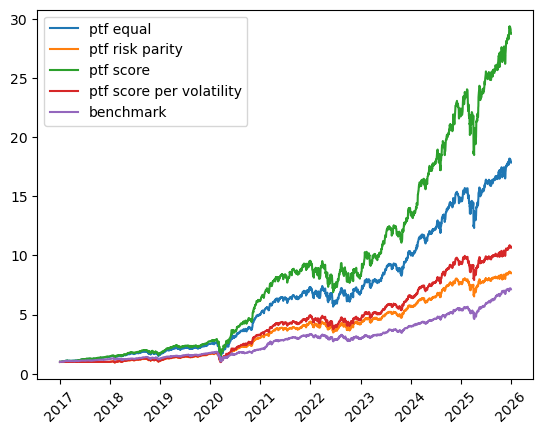

In [12]:
alpha = 0.1 # Long the top 10% equities based on the ML score
portfolio  = Backtest(screen,alpha = alpha)
daily = {
            'benchmark': pd.DataFrame(portfolio[1]['benchmark'].drop_duplicates().values,
                                      columns = ['returns']
                                     )
        }
daily['benchmark']['ptf'] = (1+daily['benchmark']['returns']).cumprod()
daily['benchmark']['turnover_oneway'] = 0

for method in ['equal','risk parity','score','score per volatility']:
 
    daily[method] = Backtest(screen,alpha=alpha,
                             weight_method=method,
                             short=False,
                             neutral=False)[0]
    
    plt.plot(daily[method].index,daily[method]['ptf_net'],label='ptf ' + method)


plt.plot(daily['score'].index,daily['benchmark']['ptf'],label='benchmark')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [13]:
metrics = ['maximum drawdown','annual return','annual volatility','sharpe','turnover','IR']
reports = { metric : [] for metric in  metrics }
reports['weight construction'] = []

for method in ['equal','risk parity','score','score per volatility']:
    report = metrics_report(daily[method])
    reports['weight construction'].append(method)
    for metric in metrics: 
        reports[metric].append(report[metric])

reports = pd.DataFrame(reports)
reports

,maximum drawdown,annual return,annual volatility,sharpe,turnover,IR,weight construction
0,0.463077,0.351779,0.246012,1.429926,0.613254,0.338695,equal
1,0.445825,0.263307,0.221576,1.188338,0.571910,0.075298,risk parity
2,0.472263,0.410194,0.266813,1.537385,0.640926,0.493077,score
3,0.460617,0.291242,0.233453,1.247538,0.586521,0.160360,score per volatility


In [14]:
def report_summary(data):
    dico = {'year':[],'sharpe':[],'annual return':[],'IR':[]}
    for year in data.index.year.unique():
        ptf_date = data[data.index.year==year]
        ret = ptf_date ['returns_net']
        ret_bench = ptf_date ['benchmark']
        sharpe   = (ret.mean() /ptf_date['returns_net'].std())*np.sqrt(252)
        IR = ((ret-ret_bench).mean())/((ret-ret_bench).std())
        dico['year'].append(year)
        dico['sharpe'].append(sharpe)
        dico['annual return'].append(ret.mean()*252)
        dico['IR'].append(IR*np.sqrt(252))

    return pd.DataFrame(dico)

In [15]:
report_summary(daily['score'])

,year,sharpe,annual return,IR
0,2017,3.553286,0.388089,1.253804
1,2018,0.912780,0.186975,0.523902
2,2019,3.084213,0.480709,0.737259
3,2020,1.902012,0.927595,0.998985
4,2021,2.309395,0.454180,-0.133994
5,2022,-0.242390,-0.087031,0.008554
6,2023,2.511243,0.538190,0.933135
7,2024,2.616237,0.489714,0.891496
8,2025,1.126488,0.308531,0.013123


In [34]:
ptf = Backtest(
                screen,
                alpha=alpha,
                weight_method='score',
                decay = 0.4,
                cost_bps = 0.0005,
                short=False,
                neutral=False
              )[1]


### Long-Short Portfolio applying a sector neutralization

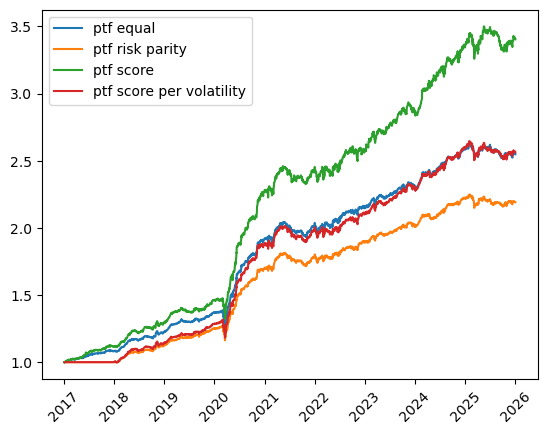

In [42]:
alpha = 0.4
portfolio  = Backtest(screen,alpha = alpha)
daily_ls = { }

for method in ['equal','risk parity','score','score per volatility']:
 
    daily_ls[method] = Backtest(screen,alpha=alpha,
                             weight_method=method,
                             short=True,
                             neutral=True)[0]
    
    plt.plot(daily_ls[method].index,daily_ls[method]['ptf_net'],label='ptf ' + method)

plt.xticks(rotation=45)
plt.legend()
plt.show()

In [43]:
metrics = ['maximum drawdown','annual return','annual volatility','sharpe','turnover']
reports = { metric : [] for metric in  metrics }
reports['weight construction'] = []

for method in ['equal','risk parity','score','score per volatility']:
    report = metrics_report(daily_ls[method])
    reports['weight construction'].append(method)
    for metric in metrics: 
        reports[metric].append(report[metric])

reports = pd.DataFrame(reports)
print(reports)

   maximum drawdown  annual return  annual volatility    sharpe  turnover  \
0          0.091655       0.105624           0.053047  1.991129  0.577908   
1          0.087748       0.088482           0.047377  1.867624  0.531610   
2          0.103182       0.138864           0.068831  2.017466  0.630094   
3          0.102521       0.106472           0.057434  1.853819  0.566617   

    weight construction  
0                 equal  
1           risk parity  
2                 score  
3  score per volatility  


In [20]:
report_summary(daily['score'])

,year,sharpe,annual return,IR
0,2017,3.149166,0.108739,-1.220216
1,2018,3.293669,0.154477,0.609372
2,2019,2.899981,0.120193,-1.483722
3,2020,3.934775,0.450966,0.469040
4,2021,1.018044,0.074842,-2.115500
5,2022,0.634629,0.053124,0.571547
6,2023,1.890876,0.104961,-1.514215
7,2024,2.652960,0.165985,-0.944322
8,2025,0.201133,0.013587,-1.364258


## Introducing Transaction cost

Assuming a transaction cost of 5 bps for each Transaction

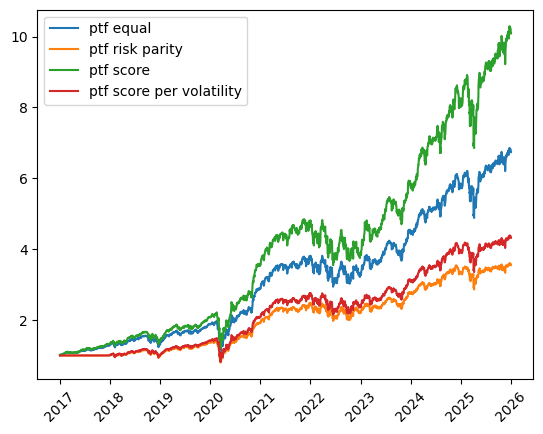

In [40]:
alpha = 0.1
portfolio  = Backtest(screen,alpha = alpha)
daily = { }

for method in ['equal','risk parity','score','score per volatility']:
 
    daily[method] = Backtest(screen,alpha=alpha,
                             weight_method=method,
                             decay = 0.4,
                             cost_bps=0.0005,
                             )[0]
    
    plt.plot(daily[method].index,daily[method]['ptf_net'],label='ptf ' + method)

plt.xticks(rotation=45)
plt.legend()
plt.show()

In [22]:
metrics = ['maximum drawdown','annual return','annual volatility','sharpe','turnover']
reports = { metric : [] for metric in  metrics }
reports['weight construction'] = []

for method in ['equal','risk parity','score','score per volatility']:
    report = metrics_report(daily[method])
    reports['weight construction'].append(method)
    for metric in metrics: 
        reports[metric].append(report[metric])

reports = pd.DataFrame(reports)
reports

,maximum drawdown,annual return,annual volatility,sharpe,turnover,weight construction
0,0.454176,0.240942,0.237401,1.014915,0.261107,equal
1,0.438157,0.164303,0.214037,0.767638,0.239350,risk parity
2,0.458158,0.290351,0.255370,1.136984,0.253808,score
3,0.450635,0.188462,0.224694,0.838750,0.234108,score per volatility


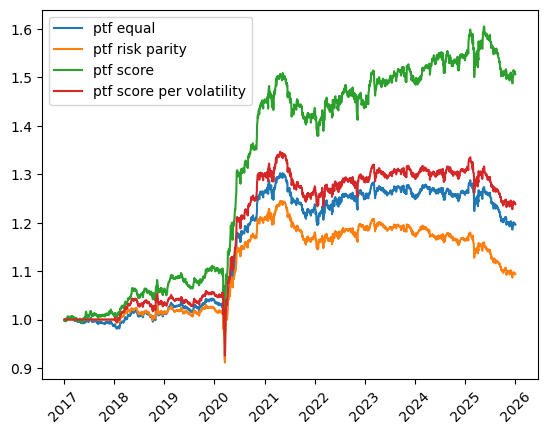

In [44]:
alpha = 0.4
portfolio  = Backtest(screen,alpha = alpha)
daily = { }

for method in ['equal','risk parity','score','score per volatility']:
 
    daily[method] = Backtest(screen,alpha=alpha,
                             weight_method=method,
                             decay = 0.4,
                             cost_bps=0.0005,
                             short=True,
                             neutral=True)[0]
    
    plt.plot(daily[method].index,daily[method]['ptf_net'],label='ptf ' + method)

plt.xticks(rotation=45)
plt.legend()
plt.show()

In [45]:
metrics = ['maximum drawdown','annual return','annual volatility','sharpe','turnover']
reports = { metric : [] for metric in  metrics }
reports['weight construction'] = []

for method in ['equal','risk parity','score','score per volatility']:
    report = metrics_report(daily[method])
    reports['weight construction'].append(method)
    for metric in metrics: 
        reports[metric].append(report[metric])

reports = pd.DataFrame(reports)
print(reports)

   maximum drawdown  annual return  annual volatility    sharpe  turnover  \
0          0.119978       0.021172           0.049726  0.425783  0.273878   
1          0.127113       0.010956           0.044216  0.247793  0.243164   
2          0.130481       0.047668           0.063177  0.754513  0.269251   
3          0.125642       0.025235           0.053023  0.475932  0.239119   

    weight construction  
0                 equal  
1           risk parity  
2                 score  
3  score per volatility  
